In [1]:
# %pip install imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import ADASYN
from collections import Counter
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [3]:
data = pd.read_csv('../../data/processed/data_selected.csv')

# Date를 날짜형으로 변환
data["Date"] = pd.to_datetime(data["Date"])

# 날짜순 정렬
data = data.sort_values("Date").reset_index(drop=True)

# 정렬 후 Date 제거
data = data.drop(columns=["Date"])

### Risk_Label을 통일하는 함수 정의

In [4]:
# Risk_Label을 0/1로 통일
# Low Risk / Low risk / low risk -> 0
# High Risk / High risk / high risk -> 1
# 이미 0/1이면 그대로 처리
    
def encode_risk_label(y_raw):
    
    if isinstance(y_raw, pd.DataFrame):
        y_raw = y_raw.iloc[:, 0]

    y_raw = y_raw.copy()

    if y_raw.dtype == object:
        y_key = (
            y_raw.astype(str)
            .str.strip()
            .str.lower()
            .str.replace(r"[\s_\-]+", " ", regex=True)
        )

        y = y_key.map({
            "low risk": 0,
            "high risk": 1,
            "0": 0,
            "1": 1
        })
    else:
        y = pd.to_numeric(y_raw, errors="coerce")

    if y.isna().any():
        print("변환 실패한 라벨:")
        print(y_raw[y.isna()].unique())
        raise ValueError("Risk_Label에 0/1로 변환되지 않은 값이 있음")

    return y.astype(int).reset_index(drop=True)

### 데이터 분할

In [5]:
# train:valid:test 45:35:20
data_train = data[:int(len(data) * 0.45)].copy()
data_valid = data[int(len(data) * 0.45):int(len(data) * 0.8)].copy()
data_test = data[int(len(data) * 0.8):].copy()

# 분할 직후 Risk_Label 인코딩
data_train["Risk_Label"] = encode_risk_label(data_train["Risk_Label"]).values
data_valid["Risk_Label"] = encode_risk_label(data_valid["Risk_Label"]).values
data_test["Risk_Label"] = encode_risk_label(data_test["Risk_Label"]).values

drop_cols = ["Risk_Label"]

X_train = data_train.drop(columns=drop_cols, errors="ignore")
y_train = data_train["Risk_Label"].astype(int)

X_valid = data_valid.drop(columns=drop_cols, errors="ignore")
y_valid = data_valid["Risk_Label"].astype(int)

X_test = data_test.drop(columns=drop_cols, errors="ignore")
y_test = data_test["Risk_Label"].astype(int)

label_name_map = {0: "LowRisk", 1: "HighRisk"}

print("train/valid/test:", len(data_train), len(data_valid), len(data_test))
print("y_train class:", y_train.map(label_name_map).value_counts().to_dict())

train/valid/test: 1848 1438 822
y_train class: {'LowRisk': 1638, 'HighRisk': 210}


### Min-Max Scaling

In [6]:
scaler = MinMaxScaler().set_output(transform="pandas")

# train에만 fit하고 valid/test에는 같은 scaler 적용
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

print("train/valid/test:", len(data_train), len(data_valid), len(data_test))
print("y_train class:", y_train.value_counts().sort_index().to_dict())

train/valid/test: 1848 1438 822
y_train class: {0: 1638, 1: 210}


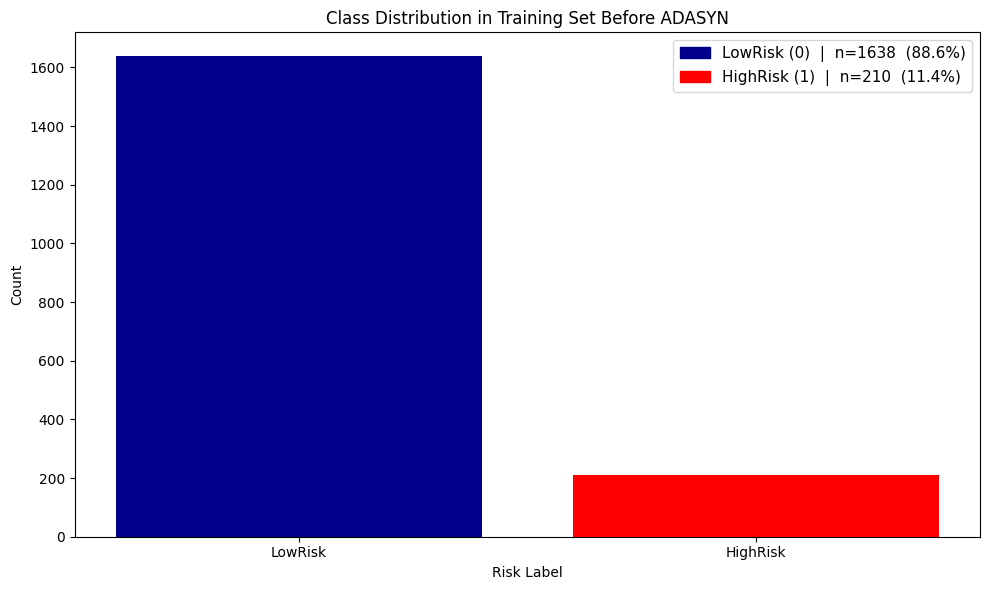

In [7]:
# 클래스 불균형 확인: train set 기준
counts = y_train.value_counts().sort_index()
label_name_map = {0: "LowRisk", 1: "HighRisk"}
colors = {0: "darkblue", 1: "red"}
total = counts.sum()

x_labels = [label_name_map.get(idx, str(idx)) for idx in counts.index]

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(
    x_labels,
    counts.values,
    color=[colors.get(k, "grey") for k in counts.index]
)

legend_labels = [
    f"{label_name_map.get(idx, idx)} ({idx})  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]

legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(idx, "grey"))
    for idx in counts.index
]

ax.legend(legend_patches, legend_labels, fontsize=11)
ax.set_xlabel("Risk Label")
ax.set_ylabel("Count")
ax.set_title("Class Distribution in Training Set Before ADASYN")
plt.tight_layout()
plt.show()

In [8]:
sampling_strategy_list = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
n_neighbors_list = [3, 5, 7]

RF_FIXED_PARAMS = {
    "n_estimators": 500,
    "max_depth": None,
    "min_samples_leaf": 5,
    "min_samples_split": 2,
    "max_features": "sqrt",
    "class_weight": None,
    "random_state": 1,
    "n_jobs": -1
}

# valid를 cutoff 선택용 65%, 최종 평가용 35%로 분할
valid_ratio = int(len(X_valid_scaled) * 0.65)

X_valid_cutoff = X_valid_scaled.iloc[:valid_ratio].copy()
y_valid_cutoff = y_valid.iloc[:valid_ratio].copy()

X_valid_eval = X_valid_scaled.iloc[valid_ratio:].copy()
y_valid_eval = y_valid.iloc[valid_ratio:].copy()

thresholds = np.arange(0.01, 0.81, 0.01)

def get_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    gmean = np.sqrt(recall * specificity)

    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # H1 = F1 score와 G-mean의 조화평균
    h1 = 2 * f1 * gmean / (f1 + gmean) if (f1 + gmean) > 0 else 0

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision,
        "Recall": recall,
        "Specificity": specificity,
        "F1": f1,
        "GMean": gmean,
        "H1": h1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

results = []

for ratio in sampling_strategy_list:
    for k in n_neighbors_list:
        try:
            adasyn = ADASYN(
                sampling_strategy=ratio,
                n_neighbors=k,
                random_state=1
            )

            X_res, y_res = adasyn.fit_resample(X_train_scaled, y_train)

            X_res = X_res.copy().reset_index(drop=True)
            y_res = pd.Series(y_res).astype(int).reset_index(drop=True)

            # Signal 더미변수 반올림
            dummy_cols = [
                col for col in X_res.columns
                if col.startswith("Signal") and (col.endswith("_Buy") or col.endswith("_Sell"))
            ]

            X_res[dummy_cols] = X_res[dummy_cols].round().astype(int)

            rf = RandomForestClassifier(**RF_FIXED_PARAMS)
            rf.fit(X_res, y_res)

            # 1) valid 앞 65%에서 cutoff 선택: H1 최대 기준
            y_cutoff_prob = rf.predict_proba(X_valid_cutoff)[:, 1]

            best_cutoff = None
            best_cutoff_h1 = -1
            best_cutoff_metrics = None

            for cutoff in thresholds:
                y_cutoff_pred = (y_cutoff_prob >= cutoff).astype(int)
                cutoff_metrics = get_metrics(y_valid_cutoff, y_cutoff_pred)

                if cutoff_metrics["H1"] > best_cutoff_h1:
                    best_cutoff_h1 = cutoff_metrics["H1"]
                    best_cutoff = cutoff
                    best_cutoff_metrics = cutoff_metrics

            # 2) valid 뒤 35%에서 성능 평가
            y_eval_prob = rf.predict_proba(X_valid_eval)[:, 1]
            y_eval_pred = (y_eval_prob >= best_cutoff).astype(int)

            eval_metrics = get_metrics(y_valid_eval, y_eval_pred)

            eval_metrics.update({
                "sampling_strategy": ratio,
                "n_neighbors": k,
                "best_cutoff": best_cutoff,
                "cutoff_H1": best_cutoff_metrics["H1"],
                "cutoff_GMean": best_cutoff_metrics["GMean"],
                "cutoff_F1": best_cutoff_metrics["F1"],
                "cutoff_Recall": best_cutoff_metrics["Recall"],
                "cutoff_Specificity": best_cutoff_metrics["Specificity"],
                "resampled_LowRisk": int((y_res == 0).sum()),
                "resampled_HighRisk": int((y_res == 1).sum())
            })

            results.append(eval_metrics)

        except Exception as e:
            results.append({
                "sampling_strategy": ratio,
                "n_neighbors": k,
                "error": str(e)
            })

search_df = pd.DataFrame(results)

if "error" in search_df.columns:
    search_df_valid = search_df[search_df["error"].isna()].copy()
else:
    search_df_valid = search_df.copy()

# ADASYN 조합 최종 선택 기준: H1 1순위
search_df_valid = search_df_valid.sort_values(
    by=["H1", "GMean", "F1", "Recall"],
    ascending=False
).reset_index(drop=True)

if "Rank" in search_df_valid.columns:
    search_df_valid = search_df_valid.drop(columns=["Rank"])

search_df_valid.insert(0, "Rank", range(1, len(search_df_valid) + 1))

display_cols = [
    "Rank",
    "sampling_strategy",
    "n_neighbors",
    "best_cutoff",
    "resampled_LowRisk",
    "resampled_HighRisk",
    "Accuracy",
    "Precision",
    "Recall",
    "Specificity",
    "F1",
    "GMean",
    "H1",
    "TN", "FP", "FN", "TP",
    "cutoff_H1",
    "cutoff_GMean",
    "cutoff_F1",
    "cutoff_Recall",
    "cutoff_Specificity"
]

display(search_df_valid[display_cols])

best_row = search_df_valid.iloc[0]

best_sampling_strategy = best_row["sampling_strategy"]
best_n_neighbors = int(best_row["n_neighbors"])
best_rf_cutoff = best_row["best_cutoff"]

print("Best sampling_strategy:", best_sampling_strategy)
print("Best n_neighbors:", best_n_neighbors)
print("Best RF cutoff:", best_rf_cutoff)
print("Validation-eval H1:", best_row["H1"])
print("Validation-eval GMean:", best_row["GMean"])
print("Validation-eval F1:", best_row["F1"])
print("Validation-eval Recall:", best_row["Recall"])
print("Validation-eval Specificity:", best_row["Specificity"])

,Rank,sampling_strategy,n_neighbors,best_cutoff,resampled_LowRisk,resampled_HighRisk,Accuracy,Precision,Recall,Specificity,...,H1,TN,FP,FN,TP,cutoff_H1,cutoff_GMean,cutoff_F1,cutoff_Recall,cutoff_Specificity
0,1,0.4,5,0.33,1638,701,0.636905,0.247619,0.675325,0.629977,...,0.465901,269,158,25,52,0.462657,0.641787,0.361702,0.485714,0.848010
1,2,0.2,5,0.31,1638,373,0.728175,0.285714,0.519481,0.765808,...,0.465337,327,100,37,40,0.472623,0.624504,0.380165,0.438095,0.890229
2,3,0.2,7,0.26,1638,354,0.688492,0.264706,0.584416,0.707260,...,0.465130,302,125,32,45,0.470907,0.632728,0.375000,0.457143,0.875754
3,4,0.7,5,0.37,1638,1069,0.632937,0.245283,0.675325,0.625293,...,0.463208,267,160,25,52,0.460875,0.651884,0.356436,0.514286,0.826297
4,5,0.3,3,0.28,1638,538,0.626984,0.241860,0.675325,0.618267,...,0.459213,264,163,25,52,0.472515,0.660289,0.367893,0.523810,0.832328
5,6,0.3,7,0.24,1638,490,0.587302,0.232653,0.740260,0.559719,...,0.456819,239,188,20,57,0.470500,0.680949,0.359420,0.590476,0.785283
6,7,0.7,3,0.34,1638,1119,0.595238,0.232068,0.714286,0.573770,...,0.452837,245,182,22,55,0.471797,0.684306,0.360000,0.600000,0.780458
7,8,1.0,5,0.36,1638,1638,0.579365,0.228916,0.740260,0.550351,...,0.451839,235,192,20,57,0.469369,0.688065,0.356164,0.619048,0.764777
8,9,0.5,5,0.31,1638,864,0.593254,0.231092,0.714286,0.571429,...,0.451581,244,183,22,55,0.467466,0.679378,0.356322,0.590476,0.781665
9,10,0.6,7,0.31,1638,971,0.585317,0.229508,0.727273,0.559719,...,0.451119,239,188,21,56,0.467124,0.684365,0.354571,0.609524,0.768396


Best sampling_strategy: 0.4
Best n_neighbors: 5
Best RF cutoff: 0.33
Validation-eval H1: 0.465901351830441
Validation-eval GMean: 0.6522566441887568
Validation-eval F1: 0.3623693379790941
Validation-eval Recall: 0.6753246753246753
Validation-eval Specificity: 0.629976580796253


### **ADA**ptive **SYN**

### Train data에 ADASYN 적용

In [9]:
# =========================
# train 데이터에만 ADASYN 적용
# =========================

X = X_train_scaled.copy().reset_index(drop=True)
y = y_train.copy().reset_index(drop=True)

adasyn = ADASYN(
    sampling_strategy=best_sampling_strategy,
    n_neighbors=best_n_neighbors,
    random_state=1
)

X_resampled, y_resampled = adasyn.fit_resample(X, y)

data_train_adasyn = X_resampled.copy().reset_index(drop=True)
data_train_adasyn["Risk_Label"] = pd.Series(y_resampled).astype(int).reset_index(drop=True)

# ADASYN 후 Signal 더미변수 반올림
dummy_cols = [
    col for col in data_train_adasyn.columns
    if col.startswith("Signal")
]

data_train_adasyn[dummy_cols] = (
    data_train_adasyn[dummy_cols]
    .round()
    .astype(int)
)

# Signal 더미변수 검증
for col in dummy_cols:
    bad_count = (~data_train_adasyn[col].isin([0, 1])).sum()
    assert bad_count == 0, f"{col}에 0/1 외 값이 남아 있음: {bad_count}개"

print("ADASYN 후 class 분포:")
print(data_train_adasyn["Risk_Label"].value_counts().sort_index())
print("✓ Signal 더미변수 0/1 반올림 완료")

ADASYN 후 class 분포:
Risk_Label
0    1638
1     701
Name: count, dtype: int64
✓ Signal 더미변수 0/1 반올림 완료


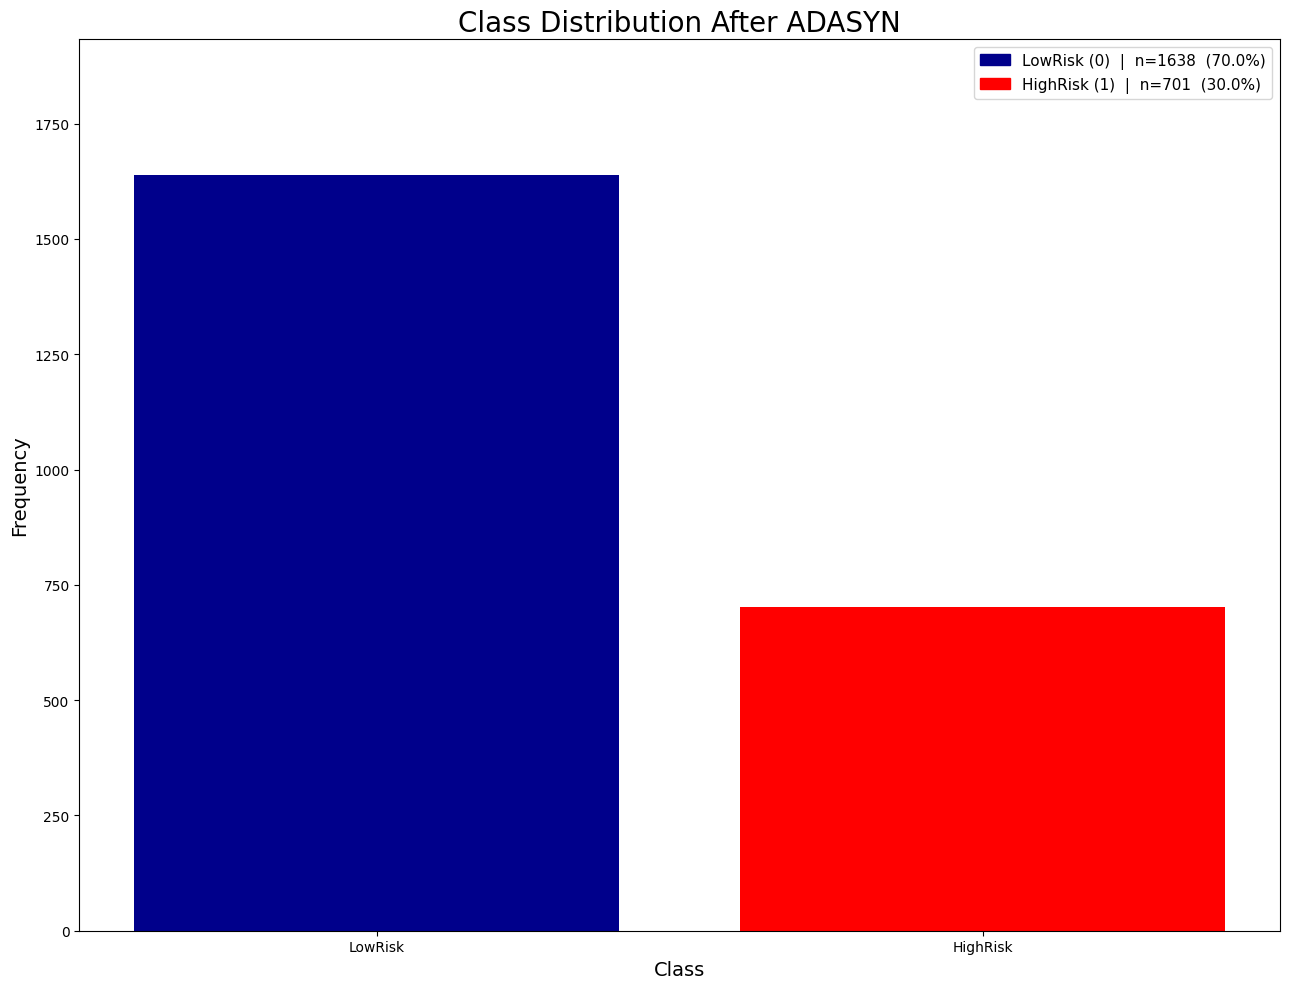

In [10]:
# 3. ADASYN 적용 후 클래스 분포 확인
counts = pd.Series(y_resampled).value_counts().sort_index()
label_name_map = {0: 'LowRisk', 1: 'HighRisk'}
colors = {0: 'darkblue', 1: 'red'}
total = counts.sum()

x_labels = [label_name_map.get(int(idx), str(idx)) for idx in counts.index]

fig, ax = plt.subplots(figsize=(13, 10))
ax.bar(
    x_labels,
    counts.values,
    color=[colors.get(int(k), 'grey') for k in counts.index]
)

# legend에 이름, index, count, 비율 표시
legend_labels = [
    f"{label_name_map.get(int(idx), idx)} ({int(idx)})  |  n={cnt}  ({cnt/total*100:.1f}%)"
    for idx, cnt in zip(counts.index, counts.values)
]
legend_patches = [
    plt.Rectangle((0, 0), 1, 1, color=colors.get(int(idx), 'grey'))
    for idx in counts.index
]
ax.legend(legend_patches, legend_labels, fontsize=11)

ax.set_xlabel('Class', fontsize=14)
ax.set_ylabel('Frequency', fontsize=14)
ax.set_title('Class Distribution After ADASYN', fontsize=20)
plt.ylim(0, max(counts.values) * 1.18)
plt.tight_layout()
plt.show()

In [11]:
# ======= [저장 직전 최종 검증] =======

data_valid_scaled = X_valid_scaled.copy().reset_index(drop=True)
data_valid_scaled["Risk_Label"] = y_valid.reset_index(drop=True).astype(int)

data_test_scaled = X_test_scaled.copy().reset_index(drop=True)
data_test_scaled["Risk_Label"] = y_test.reset_index(drop=True).astype(int)

# 컬럼 순서 검증
assert list(data_train_adasyn.drop(columns="Risk_Label").columns) == list(data_valid_scaled.drop(columns="Risk_Label").columns)
assert list(data_train_adasyn.drop(columns="Risk_Label").columns) == list(data_test_scaled.drop(columns="Risk_Label").columns)

print("=== Risk_Label 분포 검증 ===")
print(f"[train ADASYN] {data_train_adasyn['Risk_Label'].value_counts().sort_index().to_dict()}")
print(f"[valid]        {data_valid_scaled['Risk_Label'].value_counts().sort_index().to_dict()}")
print(f"[test]         {data_test_scaled['Risk_Label'].value_counts().sort_index().to_dict()}")

for name, df in [
    ("train_adasyn", data_train_adasyn),
    ("valid", data_valid_scaled),
    ("test", data_test_scaled)
]:
    bad = set(df["Risk_Label"].unique()) - {0, 1}
    assert not bad, f"[{name}] 이상한 Risk_Label 값 발견: {bad}"

print("✓ 모든 Risk_Label 정상")
print("✓ train/valid/test 컬럼 순서 동일")

=== Risk_Label 분포 검증 ===
[train ADASYN] {0: 1638, 1: 701}
[valid]        {0: 1256, 1: 182}
[test]         {0: 723, 1: 99}
✓ 모든 Risk_Label 정상
✓ train/valid/test 컬럼 순서 동일


In [12]:
# 5. CSV로 저장
data_train_adasyn.to_csv('../../data/processed/ADASYN/data_train_adasyn.csv', index=False)
data_valid_scaled.to_csv('../../data/processed/ADASYN/data_valid.csv', index=False)
data_test_scaled.to_csv('../../data/processed/ADASYN/data_test.csv', index=False)